In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

In [2]:
# Load Dataset

df = pd.read_csv("train.csv")

# Display first 5 rows
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# Check all values
print(df.isna())

         Id  MSSubClass  MSZoning  LotFrontage  LotArea  Street  Alley  \
0     False       False     False        False    False   False   True   
1     False       False     False        False    False   False   True   
2     False       False     False        False    False   False   True   
3     False       False     False        False    False   False   True   
4     False       False     False        False    False   False   True   
...     ...         ...       ...          ...      ...     ...    ...   
1455  False       False     False        False    False   False   True   
1456  False       False     False        False    False   False   True   
1457  False       False     False        False    False   False   True   
1458  False       False     False        False    False   False   True   
1459  False       False     False        False    False   False   True   

      LotShape  LandContour  Utilities  ...  PoolArea  PoolQC  Fence  \
0        False        False      False 

In [4]:
print(df.isna().sum())

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64


In [5]:
# checking duplicate rows
df.duplicated()[df.duplicated()==True]

,0


In [6]:
# finding number of rows and columns

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (1460, 81) 

number of rows:  1460
number of columns:  81


In [7]:
# viewing the data types of columns
df.dtypes

,0
Id,int64
MSSubClass,int64
MSZoning,object
LotFrontage,float64
LotArea,int64
...,...
MoSold,int64
YrSold,int64
SaleType,object
SaleCondition,object


In [8]:
df['SaleDate'] = pd.to_datetime(df['YrSold'].astype(str) + '-' + df['MoSold'].astype(str) + '-01')
df['SalePrice'] = pd.to_numeric(df['SalePrice'])

df.dtypes


,0
Id,int64
MSSubClass,int64
MSZoning,object
LotFrontage,float64
LotArea,int64
...,...
YrSold,int64
SaleType,object
SaleCondition,object
SalePrice,int64


In [9]:
# Statistical summary
df.describe(include='all')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,SaleDate
count,1460.000000,1460.000000,1460,1201.000000,1460.000000,1460,91,1460,1460,1460,...,7,281,54,1460.000000,1460.000000,1460.000000,1460,1460,1460.000000,1460
unique,NaN,NaN,5,NaN,NaN,2,2,4,4,2,...,3,4,4,NaN,NaN,NaN,9,6,NaN,NaN
top,NaN,NaN,RL,NaN,NaN,Pave,Grvl,Reg,Lvl,AllPub,...,Gd,MnPrv,Shed,NaN,NaN,NaN,WD,Normal,NaN,NaN
freq,NaN,NaN,1151,NaN,NaN,1454,50,925,1311,1459,...,3,157,49,NaN,NaN,NaN,1267,1198,NaN,NaN
mean,730.500000,56.897260,NaN,70.049958,10516.828082,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,43.489041,6.321918,2007.815753,NaN,NaN,180921.195890,2008-04-04 02:31:53.424657408
min,1.000000,20.000000,NaN,21.000000,1300.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.000000,1.000000,2006.000000,NaN,NaN,34900.000000,2006-01-01 00:00:00
25%,365.750000,20.000000,NaN,59.000000,7553.500000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.000000,5.000000,2007.000000,NaN,NaN,129975.000000,2007-04-01 00:00:00
50%,730.500000,50.000000,NaN,69.000000,9478.500000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.000000,6.000000,2008.000000,NaN,NaN,163000.000000,2008-05-01 00:00:00
75%,1095.250000,70.000000,NaN,80.000000,11601.500000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.000000,8.000000,2009.000000,NaN,NaN,214000.000000,2009-06-01 00:00:00
max,1460.000000,190.000000,NaN,313.000000,215245.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,15500.000000,12.000000,2010.000000,NaN,NaN,755000.000000,2010-07-01 00:00:00


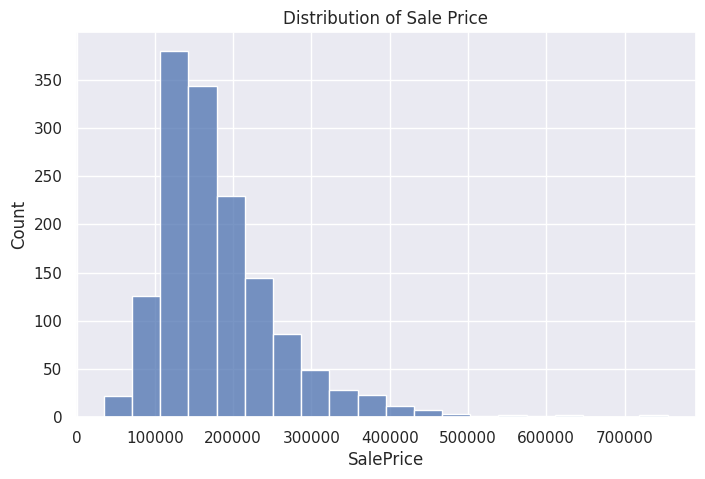

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['SalePrice'], bins=20)
plt.title("Distribution of Sale Price")
plt.show()


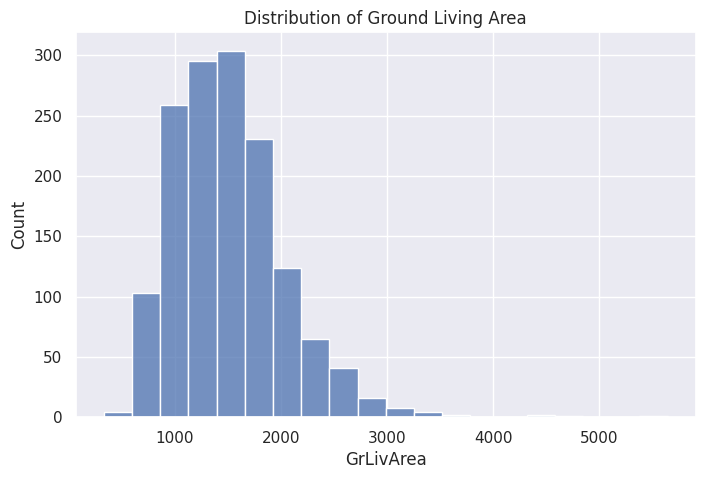

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['GrLivArea'], bins=20)
plt.title("Distribution of Ground Living Area")
plt.show()


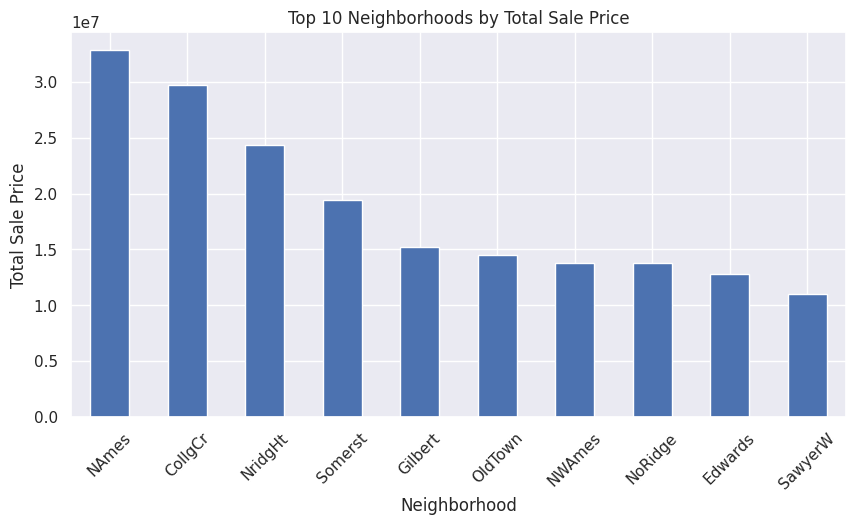

,SalePrice
Neighborhood,
NAmes,32815593
CollgCr,29694866
NridgHt,24352838
Somerst,19382666
Gilbert,15235506
OldTown,14489459
NWAmes,13800655
NoRidge,13747108
Edwards,12821970


In [14]:
neighborhood_revenue = df.groupby('Neighborhood')['SalePrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
neighborhood_revenue.plot(kind='bar')
plt.title("Top 10 Neighborhoods by Total Sale Price")
plt.ylabel("Total Sale Price")
plt.xticks(rotation=45)
plt.show()

neighborhood_revenue



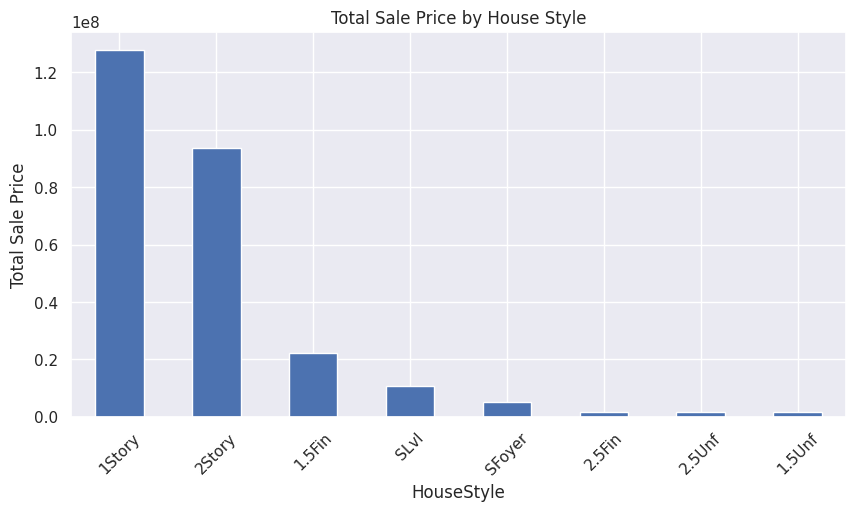

,SalePrice
HouseStyle,
1Story,127765457
2Story,93473035
1.5Fin,22039978
SLvl,10835720
SFoyer,4997756
2.5Fin,1760000
2.5Unf,1730900
1.5Unf,1542100


In [15]:
house_revenue = df.groupby('HouseStyle')['SalePrice'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
house_revenue.plot(kind='bar')
plt.title("Total Sale Price by House Style")
plt.ylabel("Total Sale Price")
plt.xticks(rotation=45)
plt.show()

house_revenue


In [17]:
saletype_avg_price = df.groupby('SaleType')['SalePrice'].mean().sort_values(ascending=False)

saletype_avg_price.head(10)



,SalePrice
SaleType,
New,274945.418033
Con,269600.000000
CWD,210600.000000
ConLI,200390.000000
WD,173401.836622
COD,143973.255814
ConLw,143700.000000
ConLD,138780.888889
Oth,119850.000000


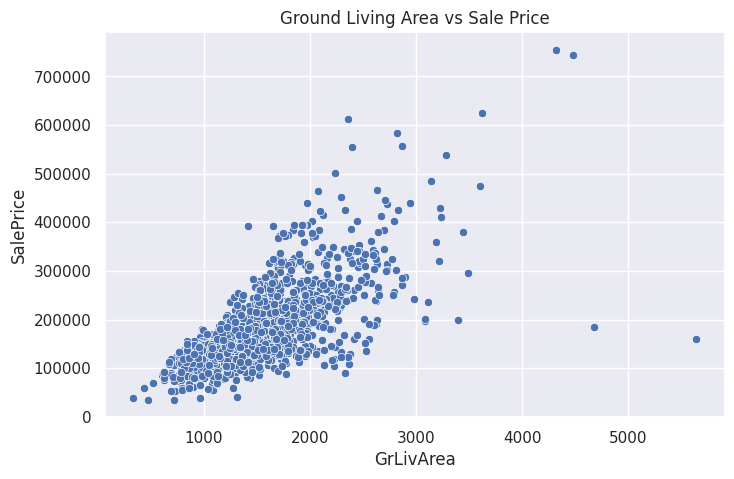

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='GrLivArea', y='SalePrice', data=df)
plt.title("Ground Living Area vs Sale Price")
plt.show()


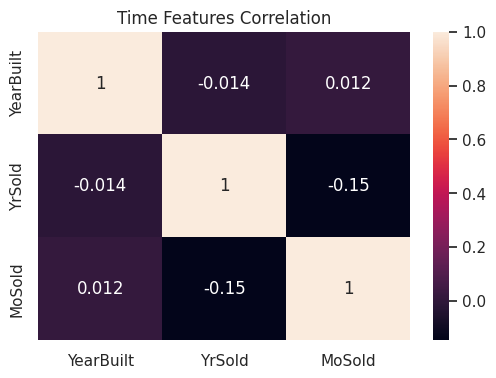

In [19]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['YearBuilt', 'YrSold', 'MoSold']].corr(), annot=True)
plt.title("Time Features Correlation")
plt.show()


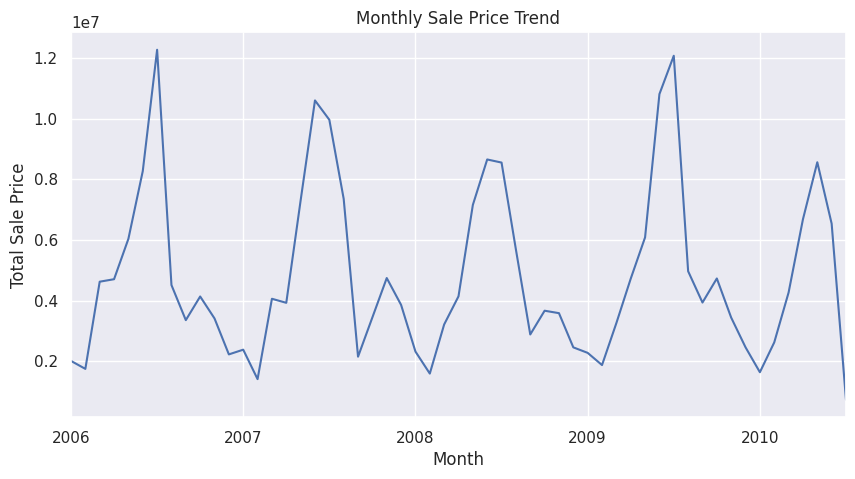

In [20]:
df['Month'] = df['SaleDate'].dt.to_period('M')

monthly_sales = df.groupby('Month')['SalePrice'].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot()
plt.title("Monthly Sale Price Trend")
plt.ylabel("Total Sale Price")
plt.show()
